In [84]:
## Imports

import pandas as pd
import numpy as np
import cv2, os, glob, random
import matplotlib.pyplot as plt

In [85]:
## Data imports

usrFolder = os.path.expanduser('~')
mainFolder = os.path.join(usrFolder,'Desktop','archive')
foldsPath = os.path.join(mainFolder,'Folds.csv')
dataPath = os.path.join(mainFolder,'BreaKHis_v1')


In [86]:
# Dataframe Assigning

folds = pd.read_csv(foldsPath)


# add filename for each sample in new column
folds["path"] = dataPath + os.sep + folds["filename"]

# extract information from each sample filename
meta = folds["filename"].str.extract(
    r"(SOB_(?P<cls>[BM])_(?P<subtype>[A-Z]+)-(?P<patient>\d+-[0-9A-Z]+)-\d+-\d+\.png$)"
)
folds = folds.join(meta)

# turn M and B into 1 and 0, respectively
folds["diagnosis"] = (folds["cls"] == "M").astype(int)


splits = {}

# segment data into folds, then into test/train. Assign this data to splits df
for k, fold_df in folds.groupby("fold"):
    temp = {}
    for grp, g in fold_df.groupby("grp"):
        temp[grp] = g
    splits[k] = temp


# Assign new test/training dataframes for each fold

test_df_1 = splits[1]["test"]
test_df_2 = splits[2]["test"]
test_df_3 = splits[3]["test"]
test_df_4 = splits[4]["test"]
test_df_5 = splits[5]["test"]

train_df_1 = splits[1]["train"]
train_df_2 = splits[2]["train"]
train_df_3 = splits[3]["train"]
train_df_4 = splits[4]["train"]
train_df_5 = splits[5]["train"]

In [87]:
train_df_3 = train_df_3.reset_index()
train_df_3.drop(columns=['index'], inplace=True)

In [88]:
train_df_3

,fold,mag,grp,filename,path,0,cls,subtype,patient,diagnosis
0,3,100,train,BreaKHis_v1/histology_slides/breast/benign/SOB...,/Users/haydenduncan/Desktop/archive/BreaKHis_v...,SOB_B_A-14-22549AB-100-001.png,B,A,14-22549AB,0
1,3,100,train,BreaKHis_v1/histology_slides/breast/benign/SOB...,/Users/haydenduncan/Desktop/archive/BreaKHis_v...,SOB_B_A-14-22549AB-100-002.png,B,A,14-22549AB,0
2,3,100,train,BreaKHis_v1/histology_slides/breast/benign/SOB...,/Users/haydenduncan/Desktop/archive/BreaKHis_v...,SOB_B_A-14-22549AB-100-003.png,B,A,14-22549AB,0
3,3,100,train,BreaKHis_v1/histology_slides/breast/benign/SOB...,/Users/haydenduncan/Desktop/archive/BreaKHis_v...,SOB_B_A-14-22549AB-100-004.png,B,A,14-22549AB,0
4,3,100,train,BreaKHis_v1/histology_slides/breast/benign/SOB...,/Users/haydenduncan/Desktop/archive/BreaKHis_v...,SOB_B_A-14-22549AB-100-005.png,B,A,14-22549AB,0
...,...,...,...,...,...,...,...,...,...,...
5327,3,400,train,BreaKHis_v1/histology_slides/breast/malignant/...,/Users/haydenduncan/Desktop/archive/BreaKHis_v...,SOB_M_PC-14-9146-400-020.png,M,PC,14-9146,1
5328,3,400,train,BreaKHis_v1/histology_slides/breast/malignant/...,/Users/haydenduncan/Desktop/archive/BreaKHis_v...,SOB_M_PC-14-9146-400-021.png,M,PC,14-9146,1
5329,3,400,train,BreaKHis_v1/histology_slides/breast/malignant/...,/Users/haydenduncan/Desktop/archive/BreaKHis_v...,SOB_M_PC-14-9146-400-022.png,M,PC,14-9146,1
5330,3,400,train,BreaKHis_v1/histology_slides/breast/malignant/...,/Users/haydenduncan/Desktop/archive/BreaKHis_v...,SOB_M_PC-14-9146-400-023.png,M,PC,14-9146,1


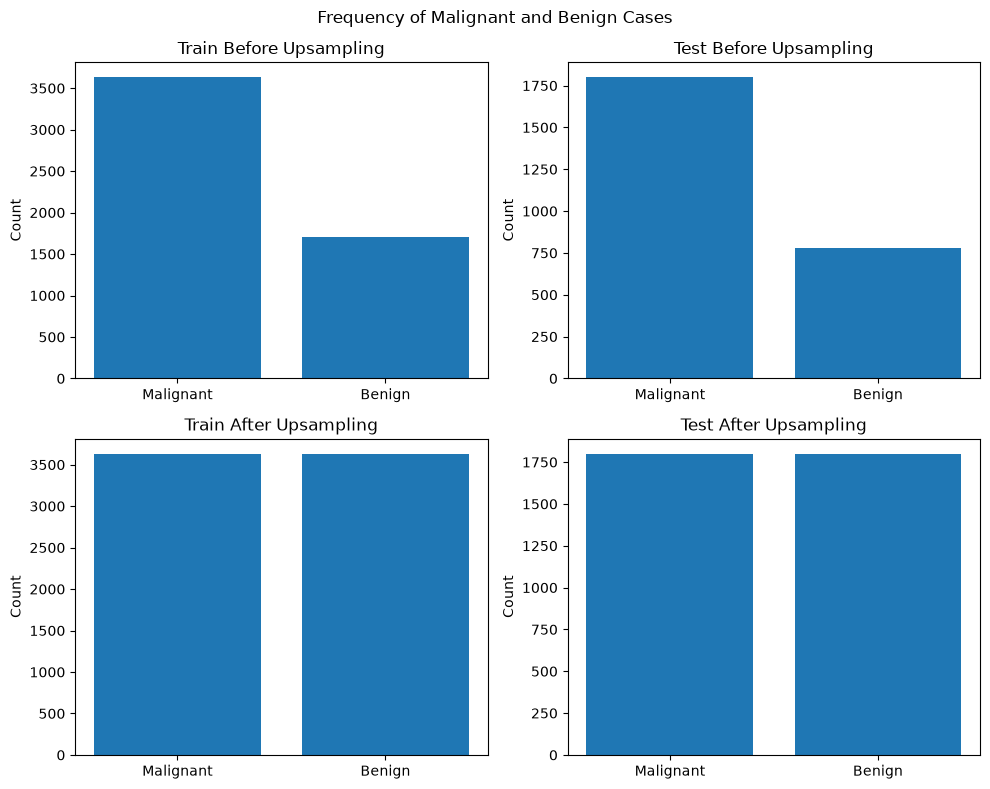

In [89]:
# Random Upsampling
def upsample(df: pd.DataFrame, label_col: str = 'diagnosis', seed: int = 42) -> pd.DataFrame:
    counts = df[label_col].value_counts()
    minority_label = counts.idxmin()

    minority = df[df[label_col] == minority_label]
    diff = counts.max() - counts.min()

    # Sample minority rows with replacement, all in one call
    extra = minority.sample(n=diff, replace=True, random_state=seed)

    # Return original data + extra samples, shuffled
    return pd.concat([df, extra]).sample(frac=1, random_state=seed).reset_index(drop=True)

train_df_3_up = upsample(train_df_3)
test_df_3_up = upsample(test_df_3)

# Examine Dataset Balance
def plot_balance(ax, df, title):
    counts = df['diagnosis'].value_counts()
    ax.bar(['Malignant', 'Benign'], [counts.get(1, 0), counts.get(0, 0)])
    ax.set_title(title)
    ax.set_ylabel("Count")

fig, ax = plt.subplots(2, 2, figsize=(10, 8))

plot_balance(ax[0, 0], train_df_3,    "Train Before Upsampling")
plot_balance(ax[0, 1], test_df_3,     "Test Before Upsampling")
plot_balance(ax[1, 0], train_df_3_up, "Train After Upsampling")
plot_balance(ax[1, 1], test_df_3_up,  "Test After Upsampling")

fig.suptitle("Frequency of Malignant and Benign Cases")
fig.tight_layout()
plt.show()